In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
df = pd.read_excel("School data.xlsx")

In [9]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
df = pd.read_excel("School data.xlsx")

In [13]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
  School_ID    District     Block Urban_Rural  %_Math_Score  %_Language_Score  \
0     SCH_1  District_C  Block_C1       Rural         43.32             48.87   
1     SCH_2  District_A  Block_A3       Rural         81.98             83.18   
2     SCH_3  District_B  Block_B1       Rural         44.68             46.38   
3     SCH_4  District_A  Block_A1       Urban         44.86             35.20   
4     SCH_5  District_C  Block_C1       Rural         47.41             47.94   

   %_Science_Score  Teacher_Student_Ratio  Avg_Teacher_Experience_Years  \
0            48.89                   40.1                           5.7   
1            83.26                    NaN                           5.8   
2            40.19                   29.9                           7.1   
3            47.77                   24.6                           2.6   
4            50.99                   39.8                           6.1   

   Teacher_Trainings_Attended  Electricity_Avail

In [14]:
print("\nRows and Columns:", df.shape)


Rows and Columns: (5200, 17)


In [15]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['School_ID', 'District', 'Block', 'Urban_Rural', '%_Math_Score',
       '%_Language_Score', '%_Science_Score', 'Teacher_Student_Ratio',
       'Avg_Teacher_Experience_Years', 'Teacher_Trainings_Attended',
       'Electricity_Available', 'Internet_Available', 'Functional_Toilets',
       'Library_Available', '%_Marginalized_Students',
       '%_Students_With_Home_Internet', 'Parent_Literacy_Rate'],
      dtype='object')


In [16]:
print("\nData Types:")
print(df.dtypes)



Data Types:
School_ID                         object
District                          object
Block                             object
Urban_Rural                       object
%_Math_Score                     float64
%_Language_Score                 float64
%_Science_Score                  float64
Teacher_Student_Ratio            float64
Avg_Teacher_Experience_Years     float64
Teacher_Trainings_Attended         int64
Electricity_Available              int64
Internet_Available               float64
Functional_Toilets                 int64
Library_Available                  int64
%_Marginalized_Students          float64
%_Students_With_Home_Internet    float64
Parent_Literacy_Rate             float64
dtype: object


Data Cleaning

In [17]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64


In [33]:
cat_cols = df.select_dtypes(include='object').columns


In [34]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [35]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
    
print("\nDuplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicates: 0


C:\Users\Bharati\AppData\Local\Temp\ipykernel_11280\887091661.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Bharati\AppData\Local\Temp\ipykernel_11280\887091661.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

Basic Statistics

In [36]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       %_Math_Score  %_Language_Score  %_Science_Score  Teacher_Student_Ratio  \
count   5200.000000       5200.000000      5200.000000            5200.000000   
mean      60.045682         62.970896        61.338762              29.971904   
std       14.726637         16.569802        18.025438               9.705717   
min        0.326857          1.380000         1.510000               1.000000   
25%       50.197500         51.520000        48.890000              23.400000   
50%       59.850000         63.030000        61.150000              29.800000   
75%       69.972500         74.452500        73.950000              36.125000   
max      107.344878        100.000000       100.000000             100.000000   

       Avg_Teacher_Experience_Years  Teacher_Trainings_Attended  \
count                   5200.000000                 5200.000000   
mean                       8.096596                    1.995385   
std                        3.916906            

Univariate Analysis


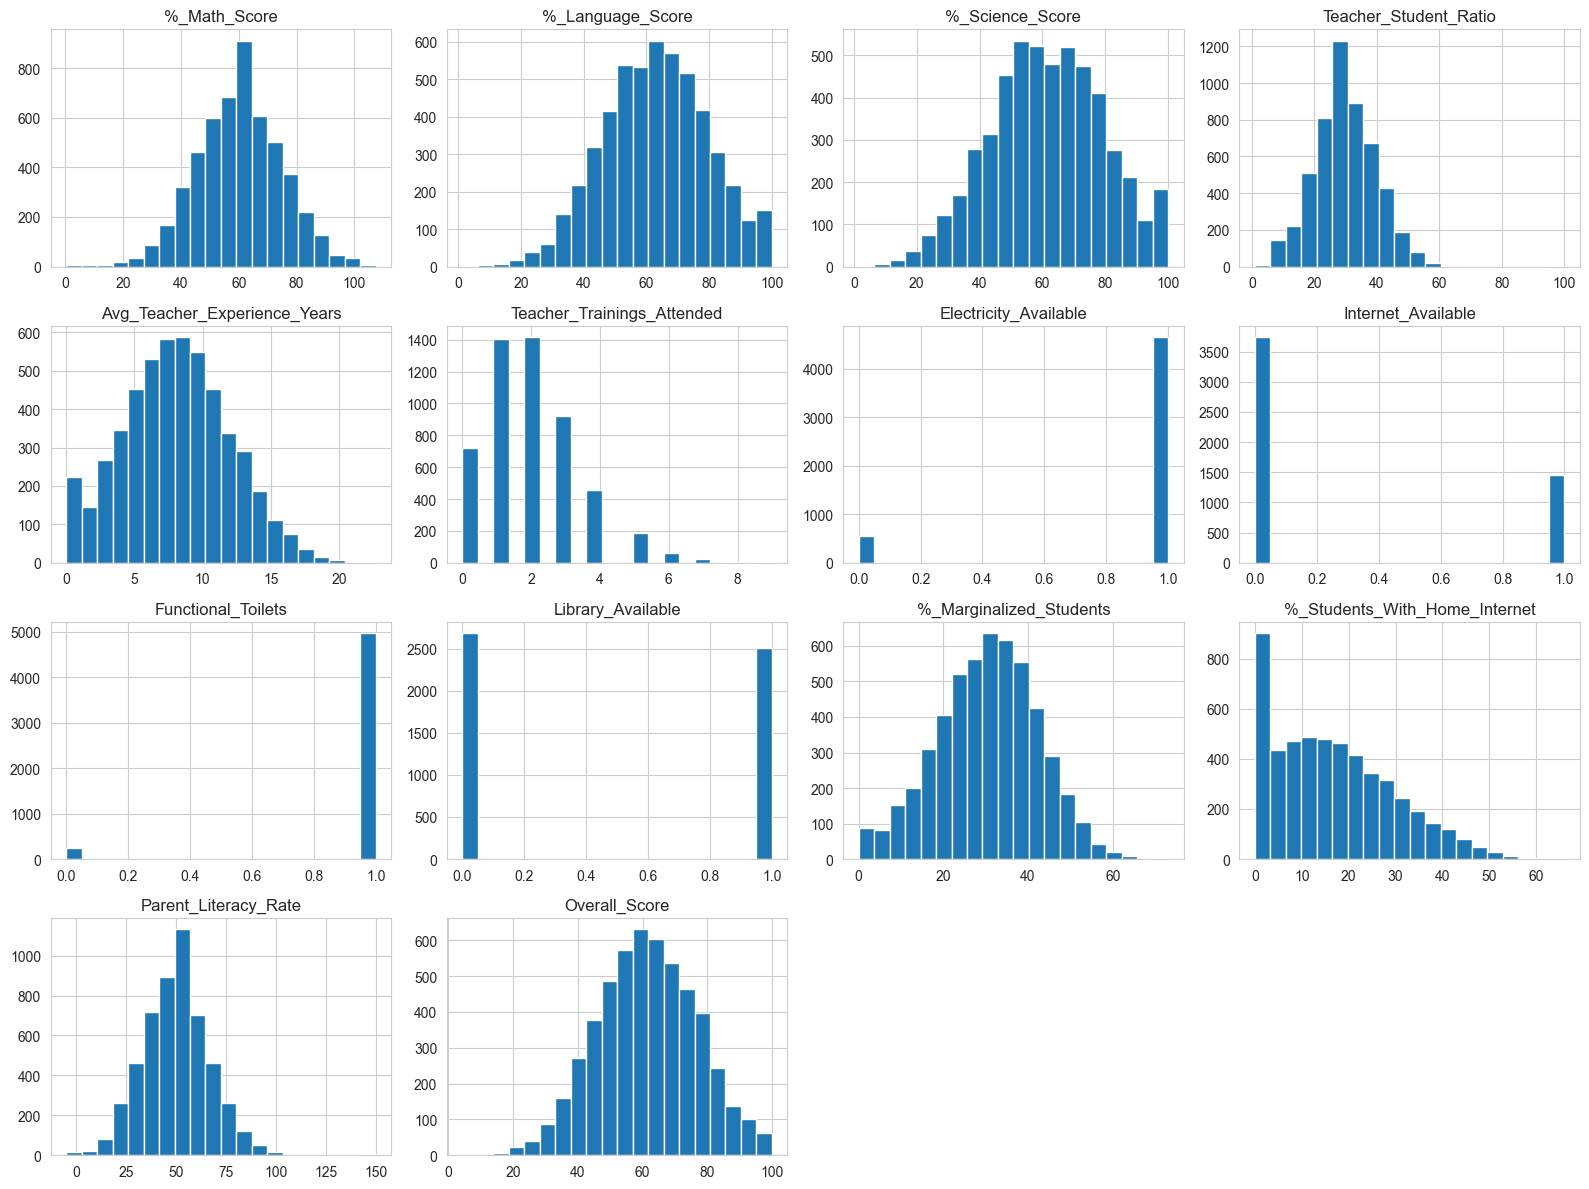

In [37]:
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

Bivariate Analysis

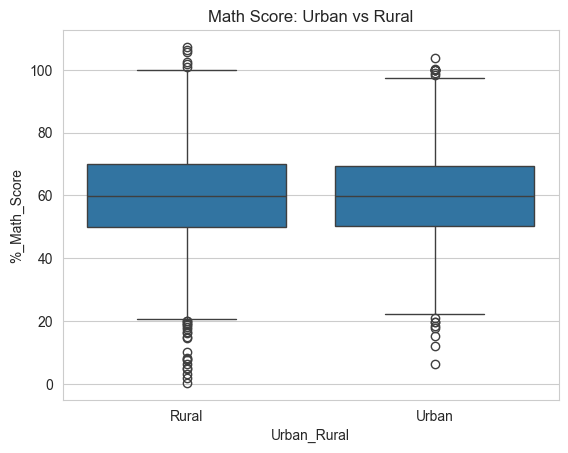

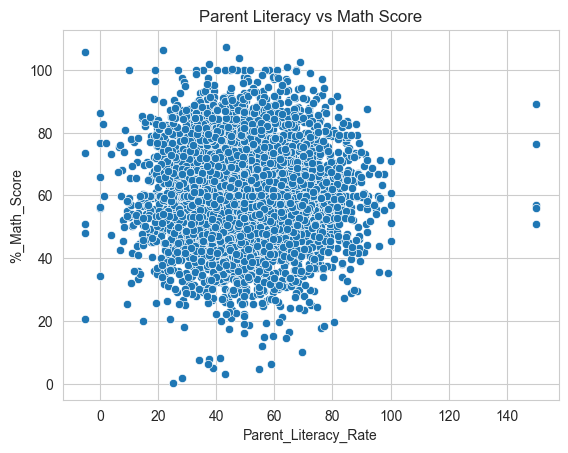

In [38]:
if 'Urban_Rural' in df.columns and '%_Math_Score' in df.columns:
    sns.boxplot(x='Urban_Rural', y='%_Math_Score', data=df)
    plt.title("Math Score: Urban vs Rural")
    plt.show()

if 'Parent_Literacy_Rate' in df.columns and '%_Math_Score' in df.columns:
    sns.scatterplot(x='Parent_Literacy_Rate', y='%_Math_Score', data=df)
    plt.title("Parent Literacy vs Math Score")
    plt.show()


Correlation Analysis

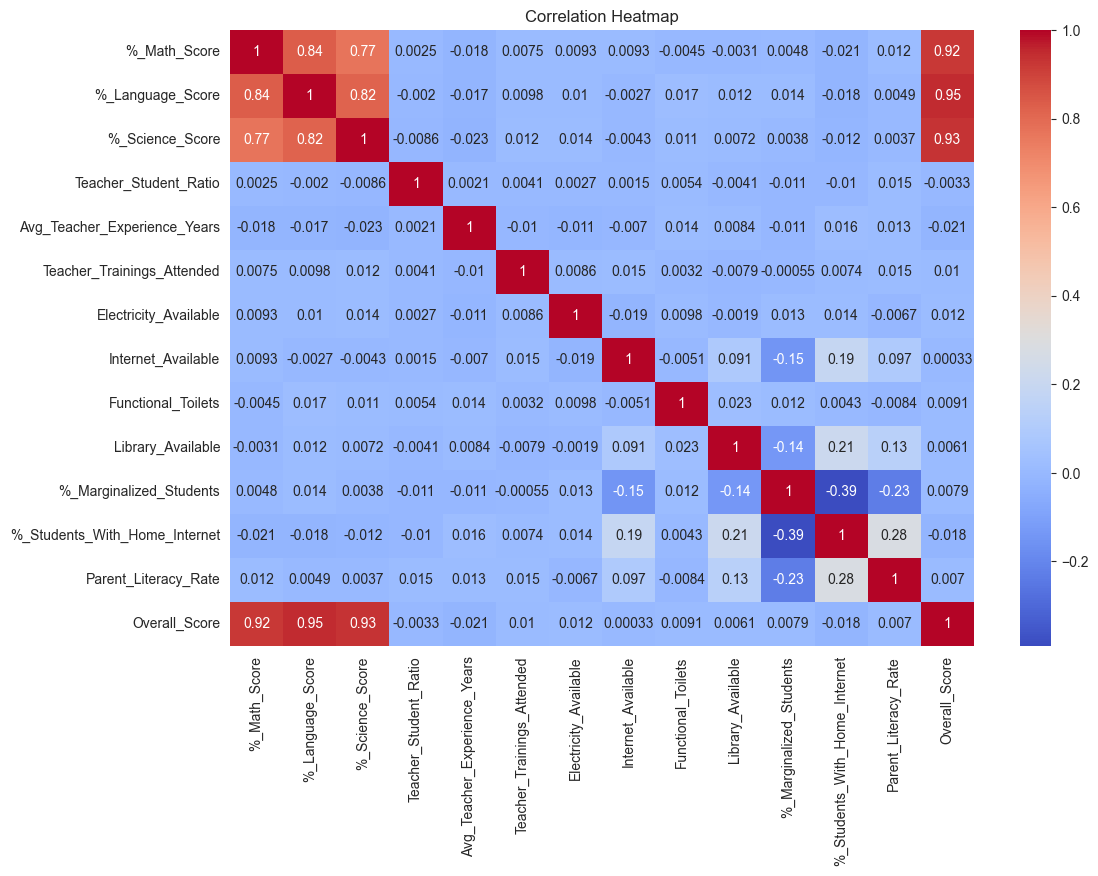

In [39]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Feature Engineering

In [40]:
if '%_Math_Score' in df.columns and '%_Language_Score' in df.columns and '%_Science_Score' in df.columns:
    df['Overall_Score'] = (
        df['%_Math_Score'] +
        df['%_Language_Score'] +
        df['%_Science_Score']
    ) / 3

    print("\nOverall Score Created Successfully")


Overall Score Created Successfully


Top Performing Schools

In [41]:
if 'School_ID' in df.columns and 'Overall_Score' in df.columns:
    top5 = df[['School_ID', 'Overall_Score']].sort_values(
        by='Overall_Score',
        ascending=False
    ).head(5)

    print("\nTop 5 Schools:")
    print(top5)


Top 5 Schools:
     School_ID  Overall_Score
1263  SCH_1264          100.0
1348  SCH_1349          100.0
4500  SCH_4501          100.0
4782  SCH_4783          100.0
650    SCH_651          100.0


Insights

In [42]:
print("\nInsights:")
print("1. Scores in Math, Language, Science are positively related.")
print("2. Parent literacy affects student performance.")
print("3. Internet access helps learning.")
print("4. Some schools need better teacher allocation.")
print("5. Urban and rural performance is nearly similar.")


Insights:
1. Scores in Math, Language, Science are positively related.
2. Parent literacy affects student performance.
3. Internet access helps learning.
4. Some schools need better teacher allocation.
5. Urban and rural performance is nearly similar.
